# Hanks Lab — Raw Doric Fiber Photometry Demo

This notebook demonstrates how to read and visualize the raw lock-in fiber photometry
data stored in an NWB file produced by `hanks-lab-to-nwb`.

The NWB file contains dLight 3.8 dopamine signals acquired simultaneously from up to
four brain regions (NAc, DMS, DLS, PL/TS) using a Doric FP Console.  Each region is
measured at two excitation wavelengths:
- **~415/420 nm** — isosbestic control (motion/bleaching artefact, dopamine-insensitive)
- **490 nm** — dopamine-sensitive dLight signal

Lock-in demodulation is performed on-board by the Doric system before writing to disk.

The file stores **two `FiberPhotometryResponseSeries`**, each with shape `(n_samples, 4)`:

| Series name | Signal type | Columns |
|---|---|---|
| `FiberPhotometryResponseSeriesIsosbesticControl` | ~415/420 nm isosbestic | AIN01 → AIN02 → AIN03 → AIN04 |
| `FiberPhotometryResponseSeriesRawSignal` | 490 nm dopamine signal | AIN01 → AIN02 → AIN03 → AIN04 |

The per-session AIN→brain-region mapping is stored in the `FiberPhotometryTable`.

---

In [1]:
from pathlib import Path

# ── Point this at an NWB file produced by convert_session.py ─────────────────
NWB_PATH = Path("../../../nwb_output/sub-400_ses-119974.nwb")  # stub (first 100 samples)

In [2]:
import warnings

import matplotlib.pyplot as plt
import ndx_fiber_photometry  # noqa: F401 — registers extension
import ndx_ophys_devices  # noqa: F401 — registers extension
import numpy as np
from pynwb import NWBHDF5IO

warnings.filterwarnings("ignore", category=UserWarning)

## 1. Open the NWB file and inspect high-level metadata

In [3]:
io = NWBHDF5IO(NWB_PATH, "r", load_namespaces=True)
nwb = io.read()

print("Session ID     :", nwb.session_id)
print("Session start  :", nwb.session_start_time)
print("Subject        :", nwb.subject.subject_id)
print("Species        :", nwb.subject.species)
print("Institution    :", nwb.institution)
print("Lab            :", nwb.lab)
print()
print("Session description:")
print(nwb.session_description)

Session ID     : 119974
Session start  : 2025-10-20 11:47:53-07:00
Subject        : 400
Species        : Rattus norvegicus
Institution    : University of California, Davis
Lab            : Hanks

Session description:
This session contains fiber photometry and behavioral data from a rat performing a two-arm bandit task (ClassicRLTasks). On each trial, the rat initiates at the center port and chooses either the left or right reward port. Reward probabilities are fixed within a block and switch across blocks, requiring the animal to track reward history and update port preferences. Behavioral events are controlled and recorded by Bpod. Fluorescence signals are acquired simultaneously from up to four brain regions using a Doric system with dLight 3.8 (dopamine indicator) at isosbestic and ligand excitation wavelengths.



## 2. Session start time and first fiber photometry timestamp

`session_start_time` is the absolute wall-clock time when the Doric recording began
(read from the `.doric` file's `Created` attribute).  All FP timestamps are offsets
in seconds from this reference — so `t = 0 s` corresponds to `session_start_time` and
the wall-clock time of any sample is `session_start_time + t`.

In [4]:
import datetime

session_start = nwb.session_start_time
print(f"session_start_time : {session_start}")
print()

# Grab the first FP series directly from acquisition (fp_series dict defined later)
fp_ref = next(
    obj for name, obj in nwb.acquisition.items()
    if "FiberPhotometryResponseSeries" in name
)
first_ts = float(
    fp_ref.timestamps[0] if fp_ref.timestamps is not None
    else (fp_ref.starting_time or 0.0)
)
last_ts = float(
    fp_ref.timestamps[-1] if fp_ref.timestamps is not None
    else (fp_ref.starting_time or 0.0) + fp_ref.data.shape[0] / fp_ref.rate
)
n = fp_ref.data.shape[0]

first_wall = session_start + datetime.timedelta(seconds=first_ts)
last_wall  = session_start + datetime.timedelta(seconds=last_ts)

print(f"First FP timestamp : {first_ts:.4f} s  →  wall clock: {first_wall}")
print(f"Last  FP timestamp : {last_ts:.4f} s  →  wall clock: {last_wall}")
print(f"Total samples      : {n:,}  ({last_ts - first_ts:.1f} s duration)")

session_start_time : 2025-10-20 11:47:53-07:00

First FP timestamp : 0.0831 s  →  wall clock: 2025-10-20 11:47:53.083083-07:00
Last  FP timestamp : 4427.6547 s  →  wall clock: 2025-10-20 13:01:40.654671-07:00
Total samples      : 26,672,119  (4427.6 s duration)


## 3. Fiber photometry hardware configuration

In [5]:
fp_meta = nwb.lab_meta_data["fiber_photometry"]
fp_table = fp_meta.fiber_photometry_table

print("FiberPhotometryTable —", fp_table.description)
print()
fp_df = fp_table.to_dataframe()
# Simplify device columns to names only
for col in ["optical_fiber", "excitation_source", "photodetector", "indicator"]:
    if col in fp_df.columns:
        fp_df[col] = fp_df[col].apply(
            lambda x: x.name if hasattr(x, "name") else str(x)
        )
display_cols = ["location", "excitation_wavelength_in_nm", "emission_wavelength_in_nm",
                "optical_fiber", "excitation_source", "photodetector"]
print(fp_df[[c for c in display_cols if c in fp_df.columns]].to_string())

FiberPhotometryTable — Metadata for all fiber photometry recording sites and excitation wavelengths in this session.

                 location  excitation_wavelength_in_nm  emission_wavelength_in_nm      optical_fiber             excitation_source       photodetector
id                                                                                                                                                    
0       Nucleus accumbens                        420.0                      530.0  optical_fiber_NAc  excitation_source_isosbestic  PhotodetectorAIN01
1          Prelimbic area                        420.0                      530.0   optical_fiber_PL  excitation_source_isosbestic  PhotodetectorAIN02
2   Dorsolateral striatum                        415.0                      530.0  optical_fiber_DLS  excitation_source_isosbestic  PhotodetectorAIN03
3    Dorsomedial striatum                        415.0                      530.0  optical_fiber_DMS  excitation_source_isosbes

In [6]:
print("Optical fibers and implant coordinates:")
for name, dev in sorted(nwb.devices.items()):
    if not name.startswith("optical_fiber_"):
        continue
    ins = getattr(dev, "fiber_insertion", None)
    if ins is not None:
        ap   = getattr(ins, "insertion_position_ap_in_mm", "?")
        ml   = getattr(ins, "insertion_position_ml_in_mm", "?")
        dv   = getattr(ins, "insertion_position_dv_in_mm", "?")
        hemi = getattr(ins, "hemisphere", "?")
        print(f"  {name}: AP={ap:+.2f}, ML={ml:+.2f}, DV={dv:.2f} mm  [{hemi}]")
    else:
        print(f"  {name}: no insertion coordinates")

print()
print("Excitation sources:")
for name in ("excitation_source_isosbestic", "excitation_source_signal"):
    dev = nwb.devices.get(name)
    if dev is None:
        continue
    desc = getattr(dev, "description", None) or ""
    model = getattr(dev, "model", None)
    wl_range = getattr(model, "wavelength_range_in_nm", None)
    wl_str = f"  [{wl_range[0]:.1f}–{wl_range[-1]:.1f} nm]" if wl_range is not None else ""
    print(f"  {name}: {desc[:80].rstrip()}{wl_str}")

print()
print("Photodetectors:")
for name, dev in sorted(nwb.devices.items()):
    if not name.startswith("Photodetector"):
        continue
    model = getattr(dev, "model", None)
    det_type  = getattr(model, "detector_type", "?")
    gain      = getattr(model, "gain", "?")
    gain_unit = getattr(model, "gain_unit", "")
    wl_range  = getattr(model, "wavelength_range_in_nm", None)
    wl_str = f"{wl_range[0]:.0f}–{wl_range[-1]:.0f} nm" if wl_range is not None else "?"
    print(f"  {name}: type={det_type}, gain={gain} {gain_unit}, sensitivity={wl_str}")

print()
print("Band optical filters:")
for name, dev in sorted(nwb.devices.items()):
    if not (name.startswith("emission_filter") or name.startswith("excitation_filter")):
        continue
    model  = getattr(dev, "model", None)
    center = getattr(model, "center_wavelength_in_nm", "?")
    bw     = getattr(model, "bandwidth_in_nm", "?")
    ftype  = getattr(model, "filter_type", "?")
    print(f"  {name}: {ftype}, center={center} nm, BW={bw} nm")

print()
print("Indicator:")
for ind in fp_meta.fiber_photometry_indicators.indicators.values():
    print(f"  {ind.name} — label: {ind.label}, manufacturer: {ind.manufacturer}")

Optical fibers and implant coordinates:
  optical_fiber_DLS: AP=+0.60, ML=+3.80, DV=-3.80 mm  [left]
  optical_fiber_DMS: AP=+1.10, ML=-2.10, DV=-3.60 mm  [right]
  optical_fiber_NAc: AP=+1.60, ML=+1.60, DV=-7.20 mm  [left]
  optical_fiber_PL: AP=+3.00, ML=-0.60, DV=-3.00 mm  [right]

Excitation sources:
  excitation_source_isosbestic:   [408.5–421.5 nm]
  excitation_source_signal:   [477.0–503.0 nm]

Photodetectors:
  PhotodetectorAIN01: type=PMT, gain=7.6 V/nW, sensitivity=350–1000 nm
  PhotodetectorAIN02: type=PMT, gain=7.6 V/nW, sensitivity=350–1000 nm
  PhotodetectorAIN03: type=PMT, gain=7.6 V/nW, sensitivity=350–1000 nm
  PhotodetectorAIN04: type=PMT, gain=7.6 V/nW, sensitivity=350–1000 nm

Band optical filters:
  emission_filter: Bandpass, center=525.0 nm, BW=50.0 nm
  excitation_filter_isosbestic_DLS: Bandpass, center=415.0 nm, BW=10.0 nm
  excitation_filter_isosbestic_DMS: Bandpass, center=415.0 nm, BW=10.0 nm
  excitation_filter_isosbestic_NAc: Bandpass, center=427.5 nm, BW=1

## 4. Load FiberPhotometryResponseSeries and decode column → region mapping

Each 2D series stores one column per AIN channel.  We look up the brain region for
each column from the `FiberPhotometryTable` rows referenced by
`fiber_photometry_table_region`.

In [7]:
fp_table = nwb.lab_meta_data["fiber_photometry"].fiber_photometry_table
fp_df = fp_table.to_dataframe()

iso_series = nwb.acquisition["FiberPhotometryResponseSeriesIsosbesticControl"]
sig_series = nwb.acquisition["FiberPhotometryResponseSeriesRawSignal"]

for series in (iso_series, sig_series):
    n_samples, n_cols = series.data.shape
    row_idx = list(series.fiber_photometry_table_region.data[:])
    col_regions = [fp_df.iloc[i]["location"] for i in row_idx]
    print(f"{series.name}")
    if series.rate is not None:
        timing_str = f"rate={series.rate:.2f} Hz, starting_time={series.starting_time:.4f} s"
    else:
        t0, t1 = float(series.timestamps[0]), float(series.timestamps[-1])
        est_rate = (n_samples - 1) / (t1 - t0)
        timing_str = f"~rate={est_rate:.2f} Hz (from timestamps), t0={t0:.4f} s"
    print(f"  shape={series.data.shape}, {timing_str}, unit={series.unit}")
    print(f"  columns: {col_regions}  (table rows {row_idx})")
    print()

# Region list in column order (full Allen Atlas names) — used for plot labelling
regions = [fp_df.iloc[i]["location"] for i in iso_series.fiber_photometry_table_region.data[:]]
print("Column → region:", regions)

FiberPhotometryResponseSeriesIsosbesticControl
  shape=(26672119, 4), ~rate=6024.10 Hz (from timestamps), t0=0.0831 s, unit=a.u.
  columns: ['Nucleus accumbens', 'Prelimbic area', 'Dorsolateral striatum', 'Dorsomedial striatum']  (table rows [np.int64(0), np.int64(1), np.int64(2), np.int64(3)])

FiberPhotometryResponseSeriesRawSignal
  shape=(26672119, 4), ~rate=6024.10 Hz (from timestamps), t0=0.0831 s, unit=a.u.
  columns: ['Nucleus accumbens', 'Prelimbic area', 'Dorsolateral striatum', 'Dorsomedial striatum']  (table rows [np.int64(4), np.int64(5), np.int64(6), np.int64(7)])

Column → region: ['Nucleus accumbens', 'Prelimbic area', 'Dorsolateral striatum', 'Dorsomedial striatum']


## 5. Plot raw fluorescence — all regions, both wavelengths

Each panel shows one brain region.  Grey trace = isosbestic control (~415/420 nm).  
Coloured trace = dopamine-sensitive signal (490 nm).

Data are downsampled by 30× for display only.

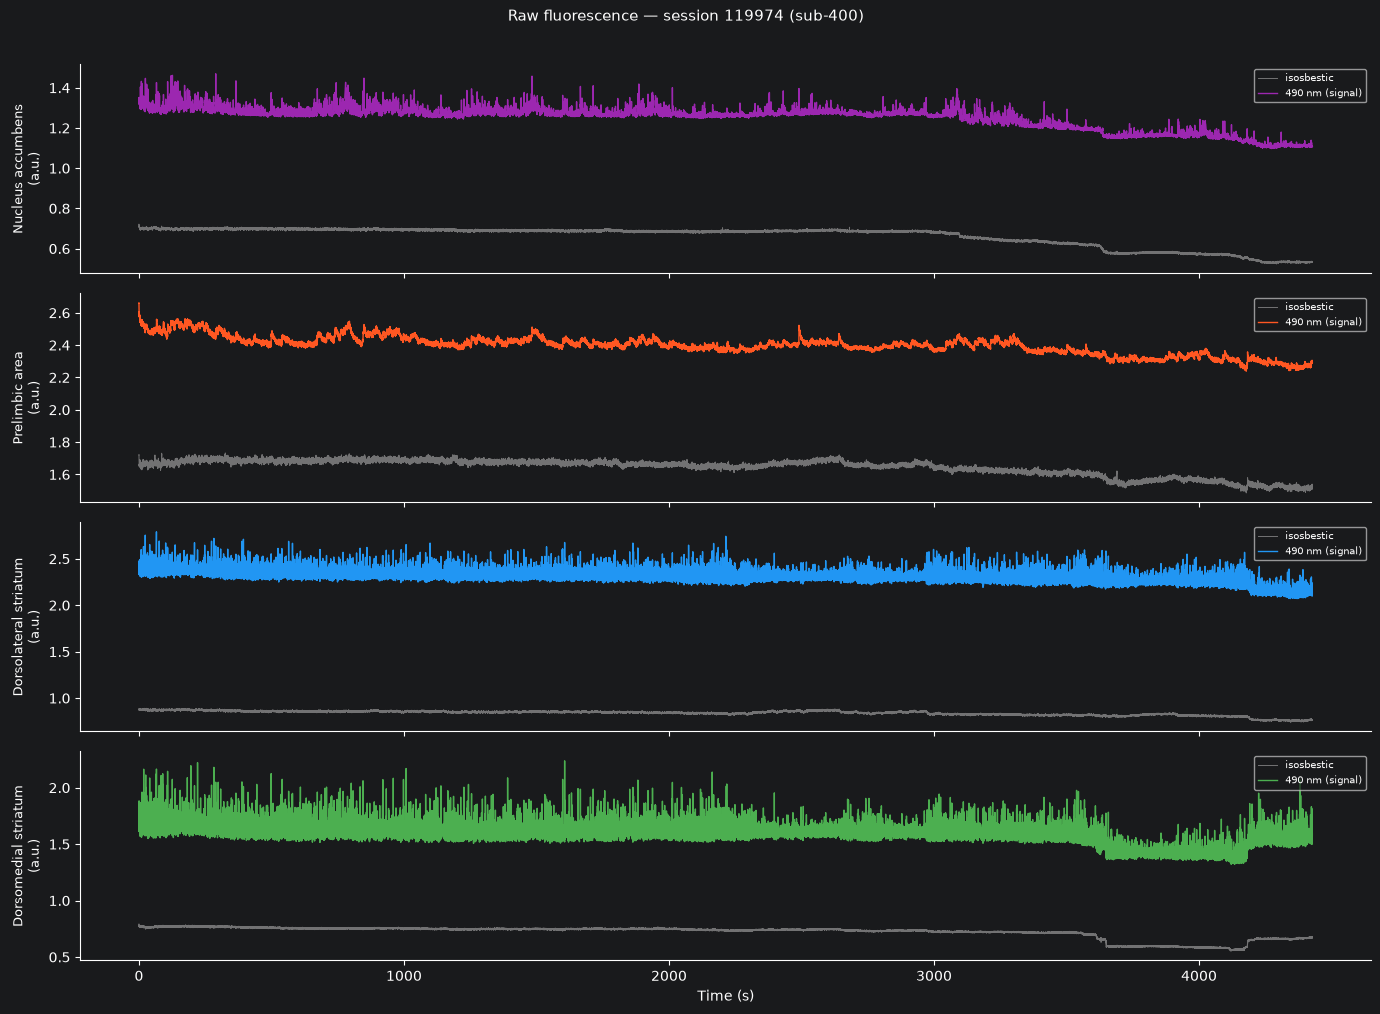

In [8]:
def series_timestamps(series, step=1):
    """Return timestamps for a series stored as rate+starting_time or explicit array."""
    n = series.data.shape[0]
    if series.timestamps is not None:
        return series.timestamps[::step]
    start = series.starting_time if series.starting_time is not None else 0.0
    return start + np.arange(0, n, step) / series.rate

SIGNAL_COLOR = {
    "Nucleus accumbens":    "#9C27B0",
    "Dorsolateral striatum": "#2196F3",
    "Dorsomedial striatum":  "#4CAF50",
    "Prelimbic area":        "#FF5722",
    "Tail of striatum":      "#FF9800",
}

step = 30
iso_ts = series_timestamps(iso_series, step=step)
sig_ts = series_timestamps(sig_series, step=step)

fig, axes = plt.subplots(len(regions), 1, figsize=(14, 2.5 * len(regions)), sharex=True)
if len(regions) == 1:
    axes = [axes]

for col_idx, (ax, region) in enumerate(zip(axes, regions)):
    color = SIGNAL_COLOR.get(region, "steelblue")
    ax.plot(iso_ts, iso_series.data[::step, col_idx],
            color="#999", lw=0.7, alpha=0.7, label="isosbestic", rasterized=True)
    ax.plot(sig_ts, sig_series.data[::step, col_idx],
            color=color, lw=1.0, alpha=1.0, label="490 nm (signal)", rasterized=True)
    ax.set_ylabel(f"{region}\n({iso_series.unit})", fontsize=9)
    ax.legend(loc="upper right", fontsize=7, framealpha=0.7)
    ax.spines[["top", "right"]].set_visible(False)

axes[-1].set_xlabel("Time (s)")
fig.suptitle(
    f"Raw fluorescence — session {nwb.session_id} (sub-{nwb.subject.subject_id})",
    y=1.01, fontsize=11,
)
plt.tight_layout()
plt.show()

## 6. Zoom into first 10 seconds at full resolution

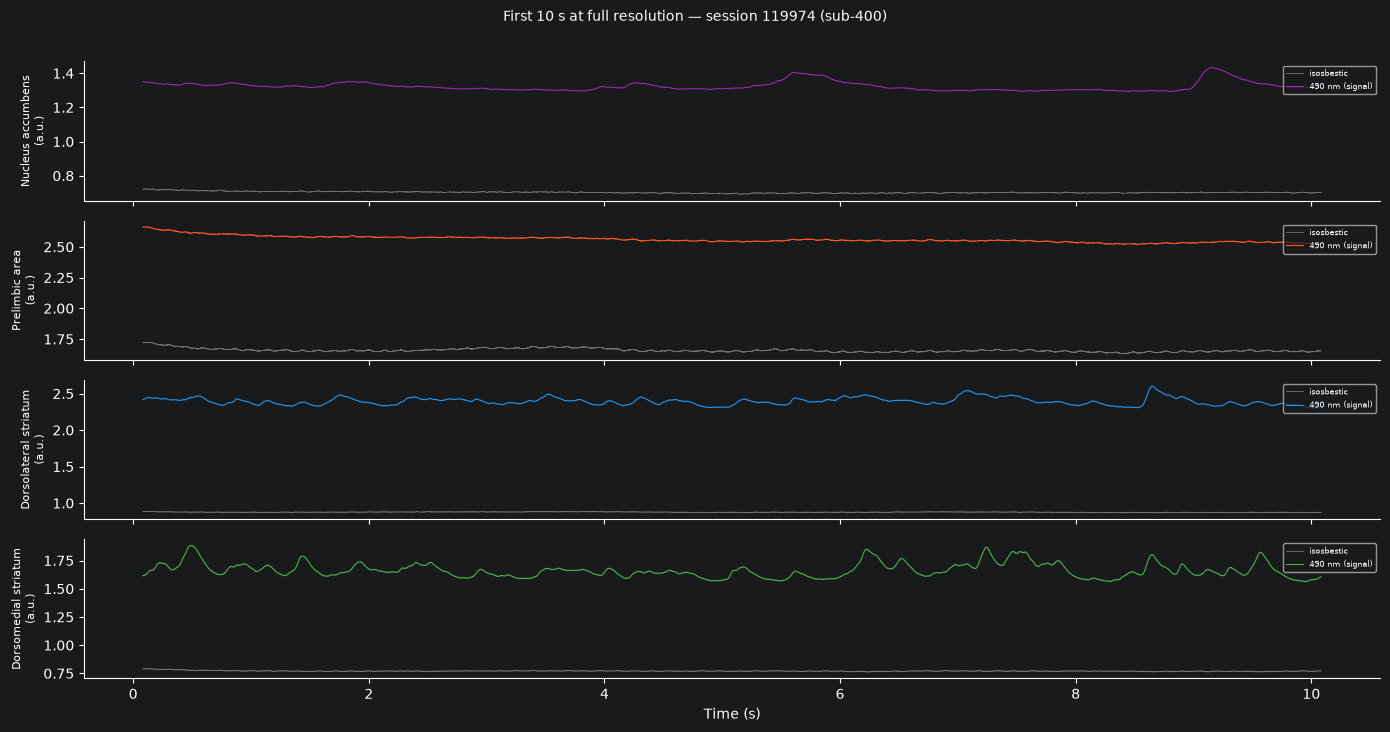

In [9]:
all_iso_ts = series_timestamps(iso_series)
all_sig_ts = series_timestamps(sig_series)

# Estimate sampling rate from timestamps (same for both series)
est_rate = (len(all_iso_ts) - 1) / (float(all_iso_ts[-1]) - float(all_iso_ts[0]))
n_10s = int(10.0 * est_rate)

iso_ts_10s = all_iso_ts[:n_10s]
sig_ts_10s = all_sig_ts[:n_10s]

fig, axes = plt.subplots(len(regions), 1, figsize=(14, 1.8 * len(regions)), sharex=True)
if len(regions) == 1:
    axes = [axes]

for col_idx, (ax, region) in enumerate(zip(axes, regions)):
    color = SIGNAL_COLOR.get(region, "steelblue")
    ax.plot(iso_ts_10s, iso_series.data[:n_10s, col_idx],
            color="#999", lw=0.6, alpha=0.7, label="isosbestic", rasterized=True)
    ax.plot(sig_ts_10s, sig_series.data[:n_10s, col_idx],
            color=color, lw=0.8, alpha=1.0, label="490 nm (signal)", rasterized=True)
    ax.set_ylabel(f"{region}\n({iso_series.unit})", fontsize=8)
    ax.legend(loc="upper right", fontsize=6, framealpha=0.7)
    ax.spines[["top", "right"]].set_visible(False)

axes[-1].set_xlabel("Time (s)")
fig.suptitle(
    f"First 10 s at full resolution — session {nwb.session_id} (sub-{nwb.subject.subject_id})",
    y=1.01, fontsize=10,
)
plt.tight_layout()
plt.show()

In [10]:
io.close()